# Notebook 13 — Generalization and robustness

## Week 8 — Out-of-distribution evaluation

Week 7 established estimator performance under the benchmark
distribution and introduced conditional evaluation and a first
controlled model-mismatch experiment.

Week 8 asks a harder question:

> **Does estimator performance survive when the test data no longer
> follow exactly the distribution used for training?**

To answer this, we use a frozen paired suite of six final
robustness regimes:

- **Test A — familiar conditions:** in-distribution reference;
- **Test B — photon-count OOD:** unseen low and high photon counts;
- **Test C — IRF mismatch:** broadened instrument response;
- **Test D — background mismatch:** elevated background;
- **Test E — temporal misalignment:** larger IRF shifts;
- **Test F — model mismatch:** bi-exponential curves passed to
  mono-exponential estimators.

Tests A–F preserve the same underlying primary lifetime
assignments and, where possible, the same paired physical design.
Only the factor defining each robustness regime is changed.

All model fitting, scaler fitting, PCA fitting, feature selection,
hyperparameter selection, and cross-validation use development
data only.

The final A–F test suite remains untouched until final evaluation.

The central scientific question is:

> **Have the estimators learned a physically meaningful relationship
> between TCSPC decay shape and fluorescence lifetime, or mainly the
> particular simulation distribution used during training?**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tcspc_toolkit.config import (
    FeatureConfig,
)
from tcspc_toolkit.generalization import (
    default_generalization_suite,
)
from tcspc_toolkit.generalization_datasets import (
    generate_generalization_test_suite,
)
from tcspc_toolkit.generalization_evaluation import (
    build_day53_ab_report,
    build_day55_model_mismatch_report,
    build_generalization_development_measurements,
    build_instrument_acquisition_diagnostics,
    evaluate_classical_instrument_acquisition_benchmark,
    evaluate_classical_model_mismatch_benchmark,
    evaluate_instrument_acquisition_benchmark,
    evaluate_ml_representation_ab_benchmark,
    evaluate_model_mismatch_benchmark,
    evaluate_principal_ab_benchmark,
    fit_generalization_ml_estimators,
    prepare_generalization_ab_data,
    prepare_generalization_data,
)
from tcspc_toolkit.irf import (
    generate_gaussian_irf,
    normalize_irf,
)

In [2]:
FEATURE_CONFIG = FeatureConfig(
    tail_start_ns=2.0,
    early_stop_ns=2.0,
    late_start_ns=3.0,
)

## Frozen robustness suite

The final A–F datasets are generated from the Week-8 protocol
using test-specific random seeds.

These datasets are final evaluation data.

They must not be used for:

- fitting ML models;
- fitting scalers;
- fitting PCA;
- feature selection;
- hyperparameter selection;
- cross-validation.

A separate familiar-domain development dataset is generated for
all such operations.

In [3]:
definition = (
    default_generalization_suite()
)

suite = (
    generate_generalization_test_suite(
        definition=definition
    )
)

development_measurements = (
    build_generalization_development_measurements(
        definition=definition
    )
)

In [4]:
print(
    "Suite version:",
    definition.suite_version,
)

print(
    "Development reference:",
    definition.development_reference,
)

print(
    "Final tests:",
    tuple(
        test.test_id
        for test in suite.tests
    ),
)

print(
    "Samples per test:",
    suite.n_samples_per_test,
)

print(
    "Time bins:",
    suite.n_time_bins,
)

print(
    "Total final histograms:",
    suite.n_total_histograms,
)

Suite version: week8-day55-v2
Development reference: week7-notebook12-benchmark
Final tests: ('A', 'B', 'C', 'D', 'E', 'F')
Samples per test: 192
Time bins: 400
Total final histograms: 1152


In [5]:
protocol_rows = []

for test in suite.tests:
    metadata = test.metadata

    protocol_rows.append(
        {
            "test_id": test.test_id,
            "regime_name": (
                metadata[
                    "regime_name"
                ].iloc[0]
            ),
            "shift": (
                metadata[
                    "shift"
                ].iloc[0]
            ),
            "changed_factors": (
                metadata[
                    "changed_factors"
                ].iloc[0]
            ),
            "decay_model": (
                metadata[
                    "decay_model"
                ].iloc[0]
            ),
            "n_samples": (
                test.y.size
            ),
        }
    )

protocol_table = pd.DataFrame(
    protocol_rows
)

protocol_table

,test_id,regime_name,shift,changed_factors,decay_model,n_samples
0,A,Familiar conditions,in_distribution,,monoexponential,192
1,B,Unseen photon-count range,photon_count,signal_photon_count,monoexponential,192
2,C,IRF-width mismatch,irf_width,irf_fwhm_ns,monoexponential,192
3,D,Elevated background,background,background_per_bin,monoexponential,192
4,E,Temporal misalignment,temporal_alignment,irf_shift_ns,monoexponential,192
5,F,Bi-exponential model mismatch,decay_model,decay_model,biexponential,192


In [6]:
def unique_values_text(
    values,
) -> str:
    unique = np.unique(
        np.asarray(values)
    )

    return ", ".join(
        str(value)
        for value in unique
    )

In [7]:
physical_rows = []

for test_id in (
    "A",
    "B",
    "C",
    "D",
    "E",
    "F",
):
    test = suite.get_test(
        test_id
    )

    metadata = test.metadata

    physical_rows.append(
        {
            "test_id": test_id,
            "lifetimes_ns": (
                unique_values_text(
                    test.y
                )
            ),
            "photon_counts": (
                unique_values_text(
                    metadata[
                        "signal_photon_count_target"
                    ]
                )
            ),
            "background_per_bin": (
                unique_values_text(
                    metadata[
                        "background_per_bin"
                    ]
                )
            ),
            "irf_fwhm_ns": (
                unique_values_text(
                    metadata[
                        "irf_fwhm_ns"
                    ]
                )
            ),
            "irf_shift_ns": (
                unique_values_text(
                    metadata[
                        "irf_shift_ns"
                    ]
                )
            ),
        }
    )

physical_protocol_table = pd.DataFrame(
    physical_rows
)

physical_protocol_table

,test_id,lifetimes_ns,photon_counts,background_per_bin,irf_fwhm_ns,irf_shift_ns
0,A,"1.0, 2.0, 3.0, 4.0","1000, 10000","0.5, 2.0","0.25, 0.4","-0.05, 0.05"
1,B,"1.0, 2.0, 3.0, 4.0","250, 500, 50000","0.5, 2.0","0.25, 0.4","-0.05, 0.05"
2,C,"1.0, 2.0, 3.0, 4.0","1000, 10000","0.5, 2.0",0.6,"-0.05, 0.05"
3,D,"1.0, 2.0, 3.0, 4.0","1000, 10000",5.0,"0.25, 0.4","-0.05, 0.05"
4,E,"1.0, 2.0, 3.0, 4.0","1000, 10000","0.5, 2.0","0.25, 0.4","-0.15, 0.15"
5,F,"1.0, 2.0, 3.0, 4.0","1000, 10000","0.5, 2.0","0.25, 0.4","-0.05, 0.05"


## Paired-test verification

The A–F tests are designed as paired robustness experiments.

The same `pair_id` and primary lifetime assignments are preserved
across all six regimes.

This allows changes in estimator performance to be interpreted
primarily as consequences of the controlled distribution shift,
rather than changes in the underlying lifetime distribution.

In [8]:
test_a = suite.get_test(
    "A"
)

reference_pair_ids = (
    test_a.metadata[
        "pair_id"
    ].to_numpy()
)

reference_lifetimes = (
    test_a.y
)

for test_id in (
    "B",
    "C",
    "D",
    "E",
    "F",
):
    test = suite.get_test(
        test_id
    )

    np.testing.assert_array_equal(
        test.metadata[
            "pair_id"
        ].to_numpy(),
        reference_pair_ids,
    )

    np.testing.assert_array_equal(
        test.y,
        reference_lifetimes,
    )

print(
    "A–F pairing verified."
)

A–F pairing verified.


# Test A vs Test B — Photon-count OOD

## Day 53

The first robustness experiment compares:

- **Test A:** familiar photon-count range;
- **Test B:** unseen photon-count regimes.

All other paired physical quantities are preserved.

The principal estimator set is:

- constant-mean baseline;
- mean-arrival-time estimator;
- Ridge;
- Random Forest;
- HistGradientBoosting;
- classical reconvolution.

For the ML estimators we additionally compare:

- engineered features;
- normalized histograms;
- PCA histograms.

For every estimator we report:

- MAE;
- median absolute error;
- RMSE;
- bias;
- P90 absolute error;
- P95 absolute error.

For classical reconvolution we additionally retain the fit-failure
rate.

Robustness is summarized by

$$
D_{\mathrm{MAE}}
=
\frac{\mathrm{MAE}_{B}}
     {\mathrm{MAE}_{A}}.
$$

Therefore:

- $D_{\mathrm{MAE}} \approx 1$ indicates little degradation;
- $D_{\mathrm{MAE}} > 1$ indicates worse performance under the
  photon-count shift;
- $D_{\mathrm{MAE}} < 1$ indicates lower MAE on Test B than on
  the familiar reference.

In [9]:
test_a = suite.get_test(
    "A"
)

test_b = suite.get_test(
    "B"
)

In [10]:
prepared_ab = (
    prepare_generalization_ab_data(
        development_measurements=(
            development_measurements
        ),
        test_a=test_a,
        test_b=test_b,
        feature_config=(
            FEATURE_CONFIG
        ),
    )
)

In [11]:
fitted_estimators_ab = (
    fit_generalization_ml_estimators(
        prepared_ab
    )
)

In [12]:
print(
    "Development samples:",
    prepared_ab.development.y.size,
)

print(
    "Test A samples:",
    prepared_ab.test_a.y.size,
)

print(
    "Test B samples:",
    prepared_ab.test_b.y.size,
)

print(
    "PCA components:",
    prepared_ab.X_pca_development.shape[1],
)

print(
    "ML estimators:",
    tuple(
        fitted_estimators_ab
    ),
)

Development samples: 64
Test A samples: 192
Test B samples: 192
PCA components: 10
ML estimators: ('ridge', 'random_forest', 'hist_gradient_boosting')


### Classical IRF convention for A/B

The Day-53 A/B classical benchmark uses a single assumed familiar
IRF.

The familiar domain contains IRF FWHM values of 0.25 ns and
0.40 ns. We use 0.40 ns as the nominal familiar IRF for this
legacy A/B benchmark.

Later, in the C/D/E analysis, classical reconvolution is evaluated
with per-curve correct IRF widths and Test C is additionally
evaluated with a deliberately incorrect familiar IRF.

In [13]:
nominal_classical_irf_fwhm_ns = max(
    definition.familiar.irf_fwhm_values_ns
)

classical_irf_ab = (
    generate_gaussian_irf(
        time=test_a.time,
        centre=(
            definition.familiar.irf_centre_ns
        ),
        fwhm=(
            nominal_classical_irf_fwhm_ns
        ),
    )
)

classical_irf_ab = (
    normalize_irf(
        time=test_a.time,
        irf=classical_irf_ab,
    )
)

print(
    "Nominal classical IRF FWHM:",
    nominal_classical_irf_fwhm_ns,
    "ns",
)

Nominal classical IRF FWHM: 0.4 ns


In [14]:
principal_ab_result = (
    evaluate_principal_ab_benchmark(
        prepared=prepared_ab,
        fitted_estimators=(
            fitted_estimators_ab
        ),
        classical_irf=(
            classical_irf_ab
        ),
        temporal_shift_bounds=(
            -0.5,
            0.5,
        ),
        classical_objective=(
            "poisson"
        ),
    )
)

In [15]:
principal_ab_result.summary

,estimator,representation,test_id,n_total_samples,n_valid_predictions,mae_ns,median_absolute_error_ns,rmse_ns,bias_ns,p90_absolute_error_ns,p95_absolute_error_ns,classical_failure_rate
0,constant_mean,none,A,192,192,1.000000,1.000000,1.118034,0.000000,1.500000,1.500000,NaN
1,mean_arrival_time,engineered_features,A,192,192,0.886204,0.411202,1.314253,0.701415,2.572090,3.127203,NaN
2,ridge,engineered_features,A,192,192,0.192582,0.138246,0.254307,-0.004503,0.413537,0.557939,NaN
3,random_forest,engineered_features,A,192,192,0.149010,0.080000,0.254453,0.025781,0.435000,0.670000,NaN
4,hist_gradient_boosting,engineered_features,A,192,192,0.219585,0.140361,0.320153,0.007208,0.548700,0.627636,NaN
5,constant_mean,none,B,192,192,1.000000,1.000000,1.118034,0.000000,1.500000,1.500000,NaN
6,mean_arrival_time,engineered_features,B,192,192,2.016260,1.596625,2.664012,1.805268,4.671705,5.288681,NaN
7,ridge,engineered_features,B,192,192,0.869301,0.741435,1.131070,0.742773,2.155805,2.409956,NaN
8,random_forest,engineered_features,B,192,192,0.428854,0.200000,0.652119,0.293750,1.155000,1.640000,NaN
9,hist_gradient_boosting,engineered_features,B,192,192,0.510743,0.308968,0.718354,0.318142,1.296229,1.654088,NaN


In [16]:
principal_ab_result.degradation

,estimator,representation,mae_a_ns,mae_b_ns,mae_degradation
0,constant_mean,none,1.000000,1.000000,1.000000
1,mean_arrival_time,engineered_features,0.886204,2.016260,2.275163
2,ridge,engineered_features,0.192582,0.869301,4.513917
3,random_forest,engineered_features,0.149010,0.428854,2.878015
4,hist_gradient_boosting,engineered_features,0.219585,0.510743,2.325951
5,classical_reconvolution,raw_histogram,0.100118,0.306067,3.057060


In [17]:
representation_ab_result = (
    evaluate_ml_representation_ab_benchmark(
        prepared=prepared_ab,
        fitted_estimators=(
            fitted_estimators_ab
        ),
    )
)

In [18]:
representation_ab_result.summary

,estimator,representation,test_id,n_total_samples,n_valid_predictions,mae_ns,median_absolute_error_ns,rmse_ns,bias_ns,p90_absolute_error_ns,p95_absolute_error_ns,classical_failure_rate
0,ridge,engineered_features,A,192,192,0.192582,0.138246,0.254307,-0.004503,0.413537,0.557939,NaN
1,ridge,normalized_histogram,A,192,192,0.235930,0.137679,0.343572,0.023815,0.626711,0.775512,NaN
2,ridge,pca_histogram,A,192,192,0.369295,0.342453,0.431530,0.049489,0.695695,0.815028,NaN
3,random_forest,engineered_features,A,192,192,0.149010,0.080000,0.254453,0.025781,0.435000,0.670000,NaN
4,random_forest,normalized_histogram,A,192,192,0.284792,0.240000,0.392686,0.017396,0.667000,0.794500,NaN
5,random_forest,pca_histogram,A,192,192,0.159375,0.060000,0.280108,0.050521,0.420000,0.779000,NaN
6,hist_gradient_boosting,engineered_features,A,192,192,0.219585,0.140361,0.320153,0.007208,0.548700,0.627636,NaN
7,hist_gradient_boosting,normalized_histogram,A,192,192,0.276143,0.201195,0.384199,0.007986,0.649998,0.843390,NaN
8,hist_gradient_boosting,pca_histogram,A,192,192,0.223028,0.152066,0.301615,-0.000119,0.505718,0.558548,NaN
9,ridge,engineered_features,B,192,192,0.869301,0.741435,1.131070,0.742773,2.155805,2.409956,NaN


In [19]:
representation_ab_result.degradation

,estimator,representation,mae_a_ns,mae_b_ns,mae_degradation
0,ridge,engineered_features,0.192582,0.869301,4.513917
1,ridge,normalized_histogram,0.235930,0.435037,1.843925
2,ridge,pca_histogram,0.369295,0.518535,1.404122
3,random_forest,engineered_features,0.149010,0.428854,2.878015
4,random_forest,normalized_histogram,0.284792,0.513750,1.803950
5,random_forest,pca_histogram,0.159375,0.513073,3.219281
6,hist_gradient_boosting,engineered_features,0.219585,0.510743,2.325951
7,hist_gradient_boosting,normalized_histogram,0.276143,0.530971,1.922809
8,hist_gradient_boosting,pca_histogram,0.223028,0.544130,2.439736


In [20]:
representation_ab_result.comparison

,estimator,representation,mae_a,median_absolute_error_a,rmse_a,bias_a,p90_absolute_error_a,p95_absolute_error_a,classical_failure_rate_a,mae_b,median_absolute_error_b,rmse_b,bias_b,p90_absolute_error_b,p95_absolute_error_b,classical_failure_rate_b,mae_degradation
0,ridge,engineered_features,0.192582,0.138246,0.254307,-0.004503,0.413537,0.557939,NaN,0.869301,0.741435,1.131070,0.742773,2.155805,2.409956,NaN,4.513917
1,ridge,normalized_histogram,0.235930,0.137679,0.343572,0.023815,0.626711,0.775512,NaN,0.435037,0.271552,0.616005,0.130610,1.086956,1.304425,NaN,1.843925
2,ridge,pca_histogram,0.369295,0.342453,0.431530,0.049489,0.695695,0.815028,NaN,0.518535,0.402692,0.656304,0.201637,1.102658,1.328362,NaN,1.404122
3,random_forest,engineered_features,0.149010,0.080000,0.254453,0.025781,0.435000,0.670000,NaN,0.428854,0.200000,0.652119,0.293750,1.155000,1.640000,NaN,2.878015
4,random_forest,normalized_histogram,0.284792,0.240000,0.392686,0.017396,0.667000,0.794500,NaN,0.513750,0.385000,0.716365,0.197396,1.179000,1.408000,NaN,1.803950
5,random_forest,pca_histogram,0.159375,0.060000,0.280108,0.050521,0.420000,0.779000,NaN,0.513073,0.185000,0.872928,0.426719,1.698000,1.930000,NaN,3.219281
6,hist_gradient_boosting,engineered_features,0.219585,0.140361,0.320153,0.007208,0.548700,0.627636,NaN,0.510743,0.308968,0.718354,0.318142,1.296229,1.654088,NaN,2.325951
7,hist_gradient_boosting,normalized_histogram,0.276143,0.201195,0.384199,0.007986,0.649998,0.843390,NaN,0.530971,0.378057,0.732338,0.233014,1.302424,1.592309,NaN,1.922809
8,hist_gradient_boosting,pca_histogram,0.223028,0.152066,0.301615,-0.000119,0.505718,0.558548,NaN,0.544130,0.397711,0.801915,0.321869,1.480757,1.588808,NaN,2.439736


In [21]:
familiar_min_photons = min(
    definition.familiar.signal_photon_counts
)

familiar_max_photons = max(
    definition.familiar.signal_photon_counts
)

In [22]:
day53_report = (
    build_day53_ab_report(
        principal_result=(
            principal_ab_result
        ),
        representation_result=(
            representation_ab_result
        ),
        familiar_min_photons=(
            familiar_min_photons
        ),
        familiar_max_photons=(
            familiar_max_photons
        ),
    )
)

In [23]:
day53_report.principal_comparison

,estimator,representation,mae_a,median_absolute_error_a,rmse_a,bias_a,p90_absolute_error_a,p95_absolute_error_a,classical_failure_rate_a,mae_b,median_absolute_error_b,rmse_b,bias_b,p90_absolute_error_b,p95_absolute_error_b,classical_failure_rate_b,mae_degradation
0,constant_mean,none,1.000000,1.000000,1.118034,0.000000,1.500000,1.500000,NaN,1.000000,1.000000,1.118034,0.000000,1.500000,1.500000,NaN,1.000000
1,mean_arrival_time,engineered_features,0.886204,0.411202,1.314253,0.701415,2.572090,3.127203,NaN,2.016260,1.596625,2.664012,1.805268,4.671705,5.288681,NaN,2.275163
2,ridge,engineered_features,0.192582,0.138246,0.254307,-0.004503,0.413537,0.557939,NaN,0.869301,0.741435,1.131070,0.742773,2.155805,2.409956,NaN,4.513917
3,random_forest,engineered_features,0.149010,0.080000,0.254453,0.025781,0.435000,0.670000,NaN,0.428854,0.200000,0.652119,0.293750,1.155000,1.640000,NaN,2.878015
4,hist_gradient_boosting,engineered_features,0.219585,0.140361,0.320153,0.007208,0.548700,0.627636,NaN,0.510743,0.308968,0.718354,0.318142,1.296229,1.654088,NaN,2.325951
5,classical_reconvolution,raw_histogram,0.100118,0.062483,0.152180,-0.039499,0.233969,0.352207,0.0,0.306067,0.179423,0.588293,-0.022948,0.645379,0.884284,0.005208,3.057060


In [24]:
day53_report.representation_comparison

,estimator,representation,mae_a,median_absolute_error_a,rmse_a,bias_a,p90_absolute_error_a,p95_absolute_error_a,classical_failure_rate_a,mae_b,median_absolute_error_b,rmse_b,bias_b,p90_absolute_error_b,p95_absolute_error_b,classical_failure_rate_b,mae_degradation
0,ridge,engineered_features,0.192582,0.138246,0.254307,-0.004503,0.413537,0.557939,NaN,0.869301,0.741435,1.131070,0.742773,2.155805,2.409956,NaN,4.513917
1,ridge,normalized_histogram,0.235930,0.137679,0.343572,0.023815,0.626711,0.775512,NaN,0.435037,0.271552,0.616005,0.130610,1.086956,1.304425,NaN,1.843925
2,ridge,pca_histogram,0.369295,0.342453,0.431530,0.049489,0.695695,0.815028,NaN,0.518535,0.402692,0.656304,0.201637,1.102658,1.328362,NaN,1.404122
3,random_forest,engineered_features,0.149010,0.080000,0.254453,0.025781,0.435000,0.670000,NaN,0.428854,0.200000,0.652119,0.293750,1.155000,1.640000,NaN,2.878015
4,random_forest,normalized_histogram,0.284792,0.240000,0.392686,0.017396,0.667000,0.794500,NaN,0.513750,0.385000,0.716365,0.197396,1.179000,1.408000,NaN,1.803950
5,random_forest,pca_histogram,0.159375,0.060000,0.280108,0.050521,0.420000,0.779000,NaN,0.513073,0.185000,0.872928,0.426719,1.698000,1.930000,NaN,3.219281
6,hist_gradient_boosting,engineered_features,0.219585,0.140361,0.320153,0.007208,0.548700,0.627636,NaN,0.510743,0.308968,0.718354,0.318142,1.296229,1.654088,NaN,2.325951
7,hist_gradient_boosting,normalized_histogram,0.276143,0.201195,0.384199,0.007986,0.649998,0.843390,NaN,0.530971,0.378057,0.732338,0.233014,1.302424,1.592309,NaN,1.922809
8,hist_gradient_boosting,pca_histogram,0.223028,0.152066,0.301615,-0.000119,0.505718,0.558548,NaN,0.544130,0.397711,0.801915,0.321869,1.480757,1.588808,NaN,2.439736


In [25]:
day53_report.photon_count_ood_summary

,estimator,representation,photon_count_regime,n_total_samples,n_valid_predictions,mae_ns,median_absolute_error_ns,rmse_ns,bias_ns,p90_absolute_error_ns,p95_absolute_error_ns
0,ridge,engineered_features,low_photon_ood,128,128,0.901376,0.611240,1.236138,0.780548,2.371303,2.543441
1,ridge,engineered_features,high_photon_ood,64,64,0.805150,0.934157,0.884245,0.667223,1.203040,1.261910
2,ridge,normalized_histogram,low_photon_ood,128,128,0.601593,0.463708,0.749955,0.212019,1.213732,1.470065
3,ridge,normalized_histogram,high_photon_ood,64,64,0.101925,0.097666,0.116276,-0.032208,0.190758,0.208067
4,ridge,pca_histogram,low_photon_ood,128,128,0.626772,0.571552,0.769335,0.358012,1.187254,1.540111
5,ridge,pca_histogram,high_photon_ood,64,64,0.302060,0.289401,0.329321,-0.111113,0.489159,0.504642
6,random_forest,engineered_features,low_photon_ood,128,128,0.593281,0.495000,0.793856,0.430625,1.582000,1.669500
7,random_forest,engineered_features,high_photon_ood,64,64,0.100000,0.100000,0.123946,0.020000,0.197000,0.200000
8,random_forest,normalized_histogram,low_photon_ood,128,128,0.722109,0.655000,0.870531,0.339609,1.363000,1.801500
9,random_forest,normalized_histogram,high_photon_ood,64,64,0.097031,0.030000,0.154551,-0.087031,0.250000,0.297000


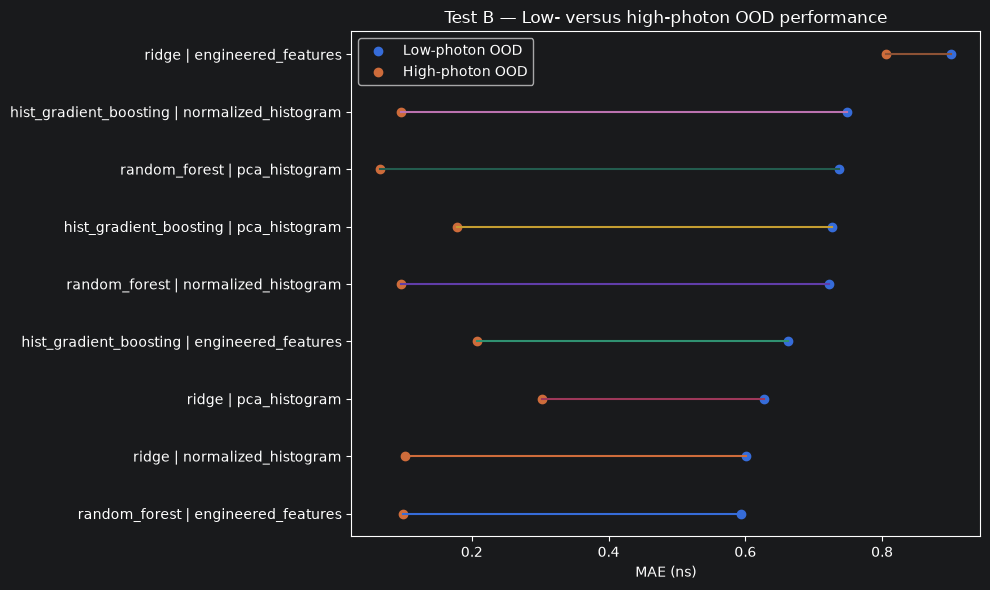

In [26]:
photon_plot = (
    day53_report
    .photon_count_ood_summary
    .copy()
)

photon_plot["label"] = (
    photon_plot["estimator"]
    + " | "
    + photon_plot["representation"]
)

photon_pivot = (
    photon_plot.pivot(
        index="label",
        columns="photon_count_regime",
        values="mae_ns",
    )
    .sort_values(
        "low_photon_ood"
    )
)

y = np.arange(
    len(photon_pivot)
)

fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.scatter(
    photon_pivot["low_photon_ood"],
    y,
    label="Low-photon OOD",
)

ax.scatter(
    photon_pivot["high_photon_ood"],
    y,
    label="High-photon OOD",
)

for index in range(
    len(photon_pivot)
):
    ax.plot(
        [
            photon_pivot[
                "low_photon_ood"
            ].iloc[index],
            photon_pivot[
                "high_photon_ood"
            ].iloc[index],
        ],
        [
            y[index],
            y[index],
        ],
    )

ax.set_yticks(
    y
)

ax.set_yticklabels(
    photon_pivot.index
)

ax.set_xlabel(
    "MAE (ns)"
)

ax.set_title(
    "Test B — Low- versus high-photon OOD performance"
)

ax.legend()

fig.tight_layout()
plt.show()

### Test-B conclusions — Photon-count OOD

Test B demonstrates that photon-count generalization is strongly asymmetric.

At the aggregate level, all informative principal estimators degrade relative to familiar Test A. For engineered-feature models, the MAE-degradation factors are approximately **4.51 for Ridge**, **2.88 for Random Forest**, and **2.33 for HistGradientBoosting**. Classical reconvolution also degrades by approximately **3.06**, although its absolute Test-B MAE remains comparatively low at about **0.306 ns**, with only a very small fit-failure rate.

Separating Test B into low- and high-photon regimes reveals the main reason for this degradation.

The **low-photon OOD regime** is substantially harder for every ML model and representation, with MAEs typically in the approximate **0.59–0.90 ns** range. In contrast, several estimators remain highly accurate when extrapolating toward the **high-photon regime**. Random Forest, for example, reaches approximately **0.066–0.100 ns MAE** depending on representation, while HistGradientBoosting with normalized histograms reaches approximately **0.096 ns**.

Therefore, the aggregate Test-B degradation is driven primarily by the photon-starved regime rather than by unfamiliar photon count in both directions.

The representation comparison is also important. Count-normalized histogram representations are often much more robust to the high-count shift than engineered features. The large high-count error of engineered-feature Ridge, despite strong performance from several histogram-based alternatives, shows that photon-count robustness is not only a property of the regression algorithm but also of the representation supplied to it.

The central Test-B result is therefore:

> **The learned lifetime relationship generalizes much more successfully toward photon-rich measurements than toward photon-starved measurements; low photon statistics remain a fundamental robustness bottleneck.**

This distinction is important because “photon-count OOD” should not be treated as a single homogeneous perturbation.


# Tests C, D and E — Instrument and acquisition mismatch

## Day 54

After testing photon-count generalization in Test B, we now examine
three different forms of distribution shift while retaining the same
paired Test-A reference:

- **Test C — IRF-width mismatch:** the IRF is broadened beyond the
  familiar training range;
- **Test D — background mismatch:** the background level is elevated;
- **Test E — temporal misalignment:** the IRF shift is increased beyond
  the familiar range.

The lifetime assignments and paired sample identities remain unchanged.

The analysis addresses three questions:

1. How strongly do the estimators degrade under IRF, background, and
   temporal-alignment shifts?
2. Are engineered features, normalized histograms, and PCA histograms
   differently sensitive to these shifts?
3. How does classical reconvolution behave when the instrument model is
   correctly specified, and what happens when Test C is deliberately
   fitted using an incorrect familiar IRF?

For Test E, the fitted temporal-shift parameter is retained explicitly
to determine whether reconvolution fitting can absorb temporal
misalignment without strongly corrupting the lifetime estimate.

## Prepare the instrument/acquisition robustness subset

The A–F suite has already been generated and verified above.

Here we simply select Tests A, C, D, and E from that frozen suite.
No new final-test histograms are generated.

In [27]:
instrument_tests = {
    test_id: suite.get_test(
        test_id
    )
    for test_id in (
        "A",
        "C",
        "D",
        "E",
    )
}

In [28]:
for test_id, test in (
    instrument_tests.items()
):
    print(
        test_id,
        "samples:",
        test.y.size,
        "| IRF widths:",
        np.unique(
            test.metadata[
                "irf_fwhm_ns"
            ]
        ),
        "| backgrounds:",
        np.unique(
            test.metadata[
                "background_per_bin"
            ]
        ),
        "| shifts:",
        np.unique(
            test.metadata[
                "irf_shift_ns"
            ]
        ),
    )

A samples: 192 | IRF widths: [0.25 0.4 ] | backgrounds: [0.5 2. ] | shifts: [-0.05  0.05]
C samples: 192 | IRF widths: [0.6] | backgrounds: [0.5 2. ] | shifts: [-0.05  0.05]
D samples: 192 | IRF widths: [0.25 0.4 ] | backgrounds: [5.] | shifts: [-0.05  0.05]
E samples: 192 | IRF widths: [0.25 0.4 ] | backgrounds: [0.5 2. ] | shifts: [-0.15  0.15]


## Development-only fitting for Tests C–E

The generic Week-8 preparation path is now used for Tests A, C, D,
and E.

As before:

- engineered features are calculated sample-wise;
- total-count normalization is sample-wise;
- PCA is fitted only on the familiar development dataset;
- ML estimators are fitted only on development data.

Tests A, C, D, and E are used only for final prediction.

The current Week-8 implementation still contains separate A/B and
A/C/D/E evaluation paths. This temporary duplication is deliberate
during active scientific development and is tracked for architectural
consolidation after Week 9.

In [29]:
prepared_instrument = (
    prepare_generalization_data(
        development_measurements=(
            development_measurements
        ),
        tests=instrument_tests,
        feature_config=(
            FEATURE_CONFIG
        ),
    )
)

In [30]:
fitted_estimators_instrument = (
    fit_generalization_ml_estimators(
        prepared_instrument
    )
)

In [31]:
print(
    "Prepared tests:",
    tuple(
        prepared_instrument.tests
    ),
)

print(
    "Development samples:",
    prepared_instrument.development.y.size,
)

print(
    "PCA components:",
    prepared_instrument.X_pca_development.shape[1],
)

print(
    "Fitted estimators:",
    tuple(
        fitted_estimators_instrument
    ),
)

Prepared tests: ('A', 'C', 'D', 'E')
Development samples: 64
PCA components: 10
Fitted estimators: ('ridge', 'random_forest', 'hist_gradient_boosting')


## Non-classical robustness benchmark

We first evaluate the baselines and ML estimators.

The same Test-A familiar reference is used for all three OOD
comparisons:

$$
D_{\mathrm{MAE},X}
=
\frac{\mathrm{MAE}_{X}}
     {\mathrm{MAE}_{A}},
\qquad
X \in \{C,D,E\}.
$$

For the ML estimators, all three representations are evaluated:

- engineered features;
- normalized histograms;
- PCA histograms.

In [32]:
instrument_result = (
    evaluate_instrument_acquisition_benchmark(
        prepared=(
            prepared_instrument
        ),
        fitted_estimators=(
            fitted_estimators_instrument
        ),
    )
)

In [33]:
assert set(
    instrument_result.summary[
        "test_id"
    ]
) == {
    "A",
    "C",
    "D",
    "E",
}

assert len(
    instrument_result.summary
) == 44

assert len(
    instrument_result.degradation
) == 33

print(
    "A/C/D/E non-classical benchmark verified."
)

A/C/D/E non-classical benchmark verified.


In [34]:
principal_instrument_summary = (
    instrument_result.summary.loc[
        (
            instrument_result.summary[
                "estimator"
            ].isin(
                {
                    "constant_mean",
                    "mean_arrival_time",
                    "ridge",
                    "random_forest",
                    "hist_gradient_boosting",
                }
            )
        )
        & (
            (
                instrument_result.summary[
                    "representation"
                ]
                == "engineered_features"
            )
            | (
                instrument_result.summary[
                    "estimator"
                ]
                == "constant_mean"
            )
        )
    ]
    [
        [
            "estimator",
            "representation",
            "test_id",
            "mae_ns",
            "median_absolute_error_ns",
            "rmse_ns",
            "bias_ns",
            "p90_absolute_error_ns",
            "p95_absolute_error_ns",
        ]
    ]
    .sort_values(
        [
            "test_id",
            "estimator",
        ]
    )
    .reset_index(
        drop=True
    )
)

principal_instrument_summary

,estimator,representation,test_id,mae_ns,median_absolute_error_ns,rmse_ns,bias_ns,p90_absolute_error_ns,p95_absolute_error_ns
0,constant_mean,none,A,1.000000,1.000000,1.118034,0.000000,1.500000,1.500000
1,hist_gradient_boosting,engineered_features,A,0.219585,0.140361,0.320153,0.007208,0.548700,0.627636
2,mean_arrival_time,engineered_features,A,0.886204,0.411202,1.314253,0.701415,2.572090,3.127203
3,random_forest,engineered_features,A,0.149010,0.080000,0.254453,0.025781,0.435000,0.670000
4,ridge,engineered_features,A,0.192582,0.138246,0.254307,-0.004503,0.413537,0.557939
5,constant_mean,none,C,1.000000,1.000000,1.118034,0.000000,1.500000,1.500000
6,hist_gradient_boosting,engineered_features,C,0.219303,0.175774,0.290384,0.020983,0.517987,0.613817
7,mean_arrival_time,engineered_features,C,0.899594,0.500762,1.301039,0.590315,2.523394,2.965948
8,random_forest,engineered_features,C,0.142083,0.080000,0.233001,0.011562,0.389000,0.480000
9,ridge,engineered_features,C,0.191179,0.142067,0.246516,-0.003180,0.384648,0.497166


In [35]:
instrument_result.summary.sort_values(
    [
        "test_id",
        "estimator",
        "representation",
    ]
).reset_index(
    drop=True
)

,estimator,representation,test_id,n_total_samples,n_valid_predictions,mae_ns,median_absolute_error_ns,rmse_ns,bias_ns,p90_absolute_error_ns,p95_absolute_error_ns,classical_failure_rate
0,constant_mean,none,A,192,192,1.000000,1.000000,1.118034,0.000000,1.500000,1.500000,NaN
1,hist_gradient_boosting,engineered_features,A,192,192,0.219585,0.140361,0.320153,0.007208,0.548700,0.627636,NaN
2,hist_gradient_boosting,normalized_histogram,A,192,192,0.276143,0.201195,0.384199,0.007986,0.649998,0.843390,NaN
3,hist_gradient_boosting,pca_histogram,A,192,192,0.223028,0.152066,0.301615,-0.000119,0.505718,0.558548,NaN
4,mean_arrival_time,engineered_features,A,192,192,0.886204,0.411202,1.314253,0.701415,2.572090,3.127203,NaN
5,random_forest,engineered_features,A,192,192,0.149010,0.080000,0.254453,0.025781,0.435000,0.670000,NaN
6,random_forest,normalized_histogram,A,192,192,0.284792,0.240000,0.392686,0.017396,0.667000,0.794500,NaN
7,random_forest,pca_histogram,A,192,192,0.159375,0.060000,0.280108,0.050521,0.420000,0.779000,NaN
8,ridge,engineered_features,A,192,192,0.192582,0.138246,0.254307,-0.004503,0.413537,0.557939,NaN
9,ridge,normalized_histogram,A,192,192,0.235930,0.137679,0.343572,0.023815,0.626711,0.775512,NaN


In [36]:
instrument_result.degradation.sort_values(
    [
        "ood_test_id",
        "estimator",
        "representation",
    ]
).reset_index(
    drop=True
)

,estimator,representation,reference_test_id,ood_test_id,reference_mae_ns,ood_mae_ns,mae_degradation
0,constant_mean,none,A,C,1.000000,1.000000,1.000000
1,hist_gradient_boosting,engineered_features,A,C,0.219585,0.219303,0.998717
2,hist_gradient_boosting,normalized_histogram,A,C,0.276143,0.286798,1.038584
3,hist_gradient_boosting,pca_histogram,A,C,0.223028,0.228769,1.025739
4,mean_arrival_time,engineered_features,A,C,0.886204,0.899594,1.015109
5,random_forest,engineered_features,A,C,0.149010,0.142083,0.953513
6,random_forest,normalized_histogram,A,C,0.284792,0.312969,1.098939
7,random_forest,pca_histogram,A,C,0.159375,0.195156,1.224510
8,ridge,engineered_features,A,C,0.192582,0.191179,0.992716
9,ridge,normalized_histogram,A,C,0.235930,0.267490,1.133767


## Classical reconvolution under controlled mismatch

Classical fitting is evaluated somewhat differently because the
instrument-response model is part of the estimator itself.

For the principal A/C/D/E evaluation:

- Test A is fitted using the correct per-curve IRF width;
- Test C is fitted using its true broadened 0.60-ns IRF;
- Test D is fitted using the correct per-curve familiar IRF width;
- Test E is fitted using the correct per-curve familiar IRF width.

The temporal shift remains a fitted reconvolution parameter.

Test C is then evaluated a second time using a deliberately incorrect
0.40-ns familiar IRF.

This separates two questions:

1. how difficult is a broadened IRF when the instrument response is
   correctly known?
2. how much additional error is introduced by IRF-model mismatch?

In [37]:
classical_instrument_result = (
    evaluate_classical_instrument_acquisition_benchmark(
        tests=(
            instrument_tests
        ),
        irf_centre_ns=(
            definition.familiar.irf_centre_ns
        ),
        nominal_irf_fwhm_ns=0.40,
        temporal_shift_bounds=(
            -0.5,
            0.5,
        ),
        objective="poisson",
    )
)

In [38]:
classical_instrument_result.summary

,estimator,representation,test_id,n_total_samples,n_valid_predictions,mae_ns,median_absolute_error_ns,rmse_ns,bias_ns,p90_absolute_error_ns,p95_absolute_error_ns,classical_failure_rate
0,classical_reconvolution_correct_irf,raw_histogram,A,192,192,0.084648,0.047601,0.134432,-0.009579,0.209295,0.345136,0.000000
1,classical_reconvolution_correct_irf,raw_histogram,C,192,186,0.095193,0.042049,0.171303,-0.015858,0.228680,0.390871,0.031250
2,classical_reconvolution_correct_irf,raw_histogram,D,192,192,0.111245,0.055244,0.216036,0.000652,0.303960,0.353520,0.000000
3,classical_reconvolution_correct_irf,raw_histogram,E,192,192,0.080428,0.044794,0.134382,0.000050,0.194385,0.329947,0.000000
4,classical_reconvolution_nominal_irf,raw_histogram,C,192,191,0.117444,0.081143,0.172830,0.051830,0.228893,0.322439,0.005208


In [39]:
classical_instrument_result.degradation

,reference_estimator,reference_test_id,ood_estimator,ood_test_id,reference_mae_ns,ood_mae_ns,mae_degradation
0,classical_reconvolution_correct_irf,A,classical_reconvolution_correct_irf,C,0.084648,0.095193,1.124578
1,classical_reconvolution_correct_irf,A,classical_reconvolution_correct_irf,D,0.084648,0.111245,1.314211
2,classical_reconvolution_correct_irf,A,classical_reconvolution_correct_irf,E,0.084648,0.080428,0.950152
3,classical_reconvolution_correct_irf,A,classical_reconvolution_nominal_irf,C,0.084648,0.117444,1.387437


## Day-54 diagnostic tables

The aggregate benchmark is now converted into three targeted
diagnostics:

1. representation-specific degradation across Tests C, D, and E;
2. paired correct-versus-wrong IRF behavior for Test C;
3. fitted temporal-shift recovery for Test E.

These diagnostics are transformations of the already computed final
predictions and classical fits; no models are refitted here.

In [40]:
instrument_diagnostics = (
    build_instrument_acquisition_diagnostics(
        nonclassical_result=(
            instrument_result
        ),
        classical_result=(
            classical_instrument_result
        ),
    )
)

### Representation robustness

For every ML estimator and OOD test, the following table compares
the MAE-degradation factor for:

- engineered features;
- normalized histograms;
- PCA histograms.

The difference columns are defined relative to engineered features.

A positive `normalized_minus_engineered` value means that the
normalized-histogram representation degraded more strongly than the
engineered representation.

A negative value means the opposite.

The same interpretation applies to `pca_minus_engineered`.

In [41]:
instrument_diagnostics.representation_comparison

,estimator,ood_test_id,degradation_engineered_features,degradation_normalized_histogram,degradation_pca_histogram,normalized_minus_engineered,pca_minus_engineered
0,hist_gradient_boosting,C,0.998717,1.038584,1.025739,0.039866,0.027021
1,random_forest,C,0.953513,1.098939,1.224510,0.145427,0.270997
2,ridge,C,0.992716,1.133767,1.001919,0.141051,0.009203
3,hist_gradient_boosting,D,2.129799,1.986080,2.367817,-0.143719,0.238019
4,random_forest,D,3.139112,1.948061,3.317320,-1.191051,0.178208
5,ridge,D,4.086796,1.777781,1.448615,-2.309015,-2.638181
6,hist_gradient_boosting,E,1.458053,1.076933,1.325767,-0.381121,-0.132286
7,random_forest,E,1.513806,1.150512,1.603922,-0.363294,0.090115
8,ridge,E,1.623130,0.952625,1.042729,-0.670505,-0.580401


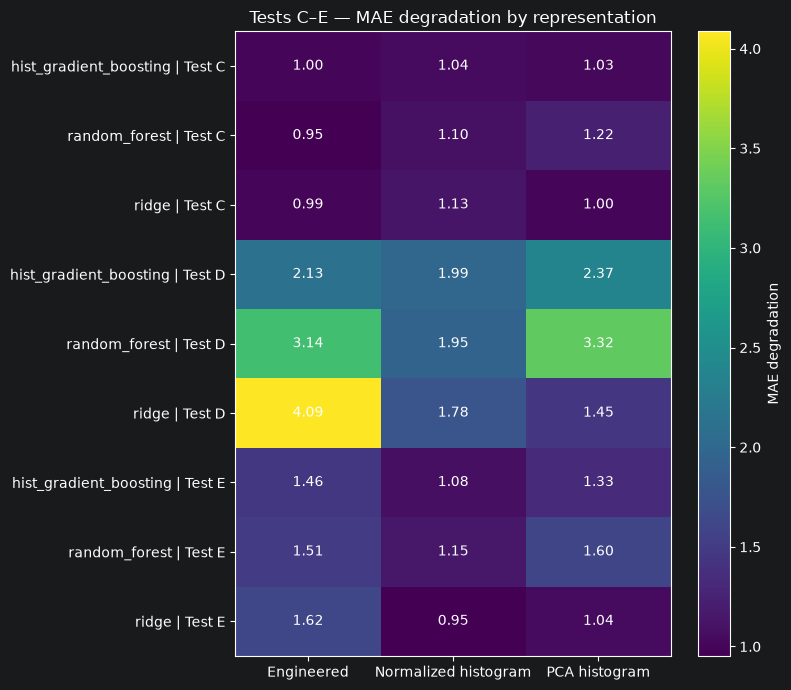

In [42]:
representation_plot = (
    instrument_diagnostics
    .representation_comparison
    .copy()
)

representation_plot["label"] = (
    representation_plot["estimator"]
    + " | Test "
    + representation_plot["ood_test_id"]
)

matrix = representation_plot[
    [
        "degradation_engineered_features",
        "degradation_normalized_histogram",
        "degradation_pca_histogram",
    ]
].to_numpy()

fig, ax = plt.subplots(
    figsize=(8, 7)
)

image = ax.imshow(
    matrix,
    aspect="auto",
)

ax.set_yticks(
    np.arange(
        len(representation_plot)
    )
)

ax.set_yticklabels(
    representation_plot["label"]
)

ax.set_xticks(
    [
        0,
        1,
        2,
    ]
)

ax.set_xticklabels(
    [
        "Engineered",
        "Normalized histogram",
        "PCA histogram",
    ]
)

for row in range(
    matrix.shape[0]
):
    for column in range(
        matrix.shape[1]
    ):
        ax.text(
            column,
            row,
            f"{matrix[row, column]:.2f}",
            ha="center",
            va="center",
        )

ax.set_title(
    "Tests C–E — MAE degradation by representation"
)

fig.colorbar(
    image,
    ax=ax,
    label="MAE degradation",
)

fig.tight_layout()
plt.show()

In [43]:
classical_instrument_result.test_c_irf_comparison

,mae_correct_irf_ns,mae_nominal_irf_ns,nominal_to_correct_mae_ratio,bias_correct_irf_ns,bias_nominal_irf_ns,p95_correct_irf_ns,p95_nominal_irf_ns,failure_rate_correct_irf,failure_rate_nominal_irf
0,0.095193,0.117444,1.23374,-0.015858,0.05183,0.390871,0.322439,0.03125,0.005208


### Paired Test-C IRF mismatch

Because the correct-IRF and nominal-IRF fits use exactly the same
Test-C histograms, they can also be compared curve by curve.

For each pair we examine:

$$
\Delta \mathrm{AE}
=
\mathrm{AE}_{\mathrm{nominal\ IRF}}
-
\mathrm{AE}_{\mathrm{correct\ IRF}},
$$

as well as changes in fitted temporal shift and Poisson deviance.

This allows us to determine whether IRF-width mismatch is expressed
primarily as lifetime error, poorer fit quality, compensating temporal
shift, or some combination of these effects.

In [44]:
instrument_diagnostics.test_c_paired_irf_summary

,n_pairs,n_both_valid,mean_absolute_error_penalty_ns,median_absolute_error_penalty_ns,mean_fitted_shift_change_ns,mean_poisson_deviance_change
0,192,185,0.022702,0.046666,-0.051126,53.670522


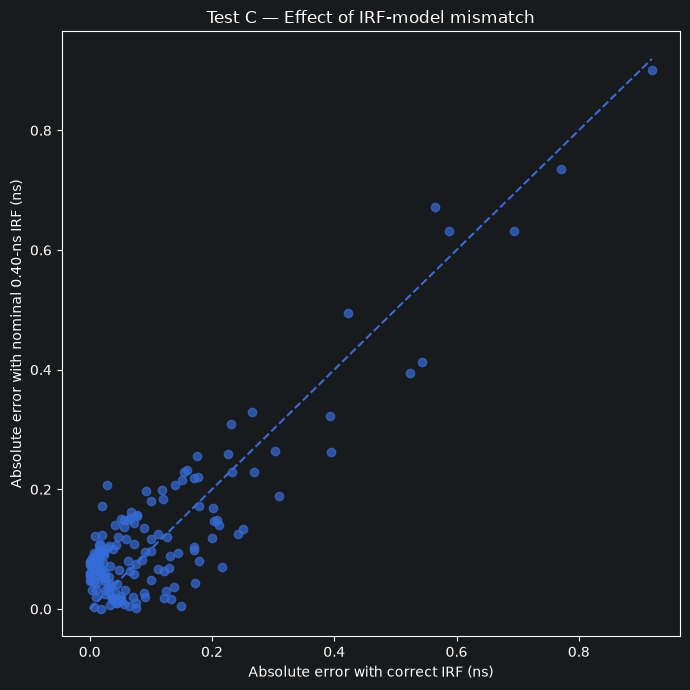

In [45]:
test_c_paired = (
    instrument_diagnostics
    .test_c_paired_irf
)

both_valid = (
    test_c_paired[
        "valid_fit_correct_irf"
    ]
    & test_c_paired[
        "valid_fit_nominal_irf"
    ]
)

test_c_valid = (
    test_c_paired.loc[
        both_valid
    ]
)

fig, ax = plt.subplots(
    figsize=(7, 7)
)

ax.scatter(
    test_c_valid[
        "absolute_error_correct_irf_ns"
    ],
    test_c_valid[
        "absolute_error_nominal_irf_ns"
    ],
    alpha=0.7,
)

limit = max(
    test_c_valid[
        "absolute_error_correct_irf_ns"
    ].max(),
    test_c_valid[
        "absolute_error_nominal_irf_ns"
    ].max(),
)

ax.plot(
    [
        0.0,
        limit,
    ],
    [
        0.0,
        limit,
    ],
    linestyle="--",
)

ax.set_xlabel(
    "Absolute error with correct IRF (ns)"
)

ax.set_ylabel(
    "Absolute error with nominal 0.40-ns IRF (ns)"
)

ax.set_title(
    "Test C — Effect of IRF-model mismatch"
)

fig.tight_layout()
plt.show()

In [46]:
instrument_diagnostics.test_c_paired_irf.head(
    10
)

,sample_id,true_lifetime_ns,fitted_lifetime_correct_irf_ns,absolute_error_correct_irf_ns,valid_fit_correct_irf,fitted_shift_correct_irf_ns,poisson_deviance_correct_irf,fitted_lifetime_nominal_irf_ns,absolute_error_nominal_irf_ns,valid_fit_nominal_irf,fitted_shift_nominal_irf_ns,poisson_deviance_nominal_irf,absolute_error_penalty_ns,fitted_shift_change_ns,poisson_deviance_change
0,0,1.0,1.072162,0.072162,True,-0.076883,401.328430,1.144522,0.144522,True,-0.131789,418.596147,0.072360,-0.054906,17.267717
1,1,1.0,1.012124,0.012124,True,-0.055034,412.250802,1.085513,0.085513,True,-0.122777,629.934345,0.073389,-0.067742,217.683543
2,2,1.0,0.994244,0.005756,True,-0.015733,412.998381,1.073019,0.073019,True,-0.077024,430.286540,0.067263,-0.061291,17.288159
3,3,1.0,1.000950,0.000950,True,-0.046367,417.862607,1.077809,0.077809,True,-0.116517,634.641494,0.076859,-0.070150,216.778887
4,4,1.0,1.344223,0.344223,False,0.000000,526.973253,1.087133,0.087133,True,-0.118246,451.383699,-0.257090,-0.118246,-75.589555
5,5,1.0,1.024090,0.024090,True,-0.059897,389.305813,1.095136,0.095136,True,-0.125996,576.098105,0.071047,-0.066100,186.792293
6,6,1.0,0.957894,0.042106,True,0.029135,387.310806,1.028257,0.028257,True,-0.020974,393.735447,-0.013849,-0.050109,6.424641
7,7,1.0,1.021773,0.021773,True,0.042179,404.618894,1.095794,0.095794,True,-0.025764,607.492666,0.074022,-0.067943,202.873772
8,8,1.0,1.046541,0.046541,True,-0.012386,405.491678,1.120111,0.120111,True,-0.065612,410.044232,0.073570,-0.053226,4.552554
9,9,1.0,1.016853,0.016853,True,0.038730,393.025953,1.088166,0.088166,True,-0.026379,599.440921,0.071313,-0.065108,206.414968


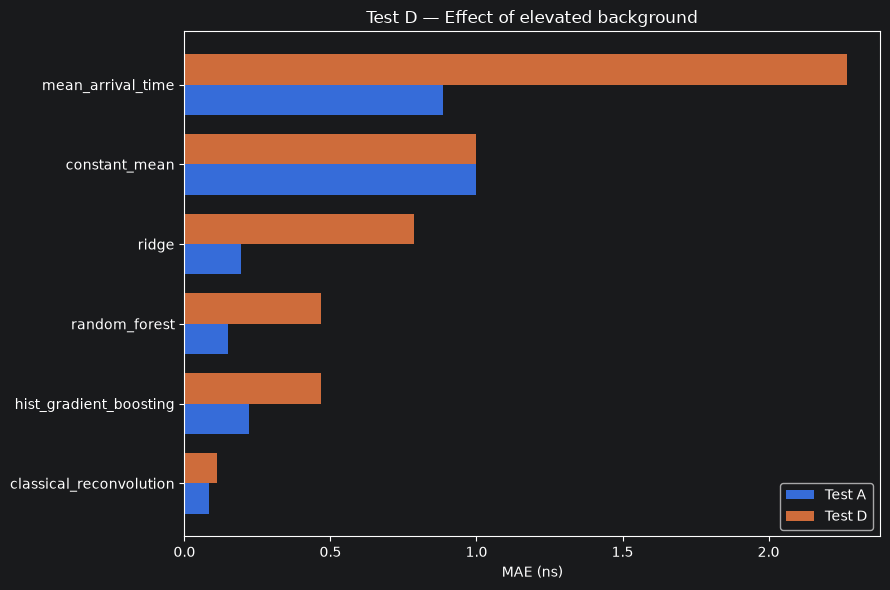

In [47]:
test_d_nonclassical = (
    principal_instrument_summary.loc[
        principal_instrument_summary[
            "test_id"
        ].isin(
            [
                "A",
                "D",
            ]
        )
    ]
    .pivot(
        index="estimator",
        columns="test_id",
        values="mae_ns",
    )
)

test_d_classical = (
    classical_instrument_result
    .summary.loc[
        (
            classical_instrument_result
            .summary["estimator"]
            == "classical_reconvolution_correct_irf"
        )
        & (
            classical_instrument_result
            .summary["test_id"]
            .isin(
                [
                    "A",
                    "D",
                ]
            )
        )
    ]
)

classical_a = float(
    test_d_classical.loc[
        test_d_classical["test_id"] == "A",
        "mae_ns",
    ].iloc[0]
)

classical_d = float(
    test_d_classical.loc[
        test_d_classical["test_id"] == "D",
        "mae_ns",
    ].iloc[0]
)

test_d_nonclassical.loc[
    "classical_reconvolution"
] = [
    classical_a,
    classical_d,
]

test_d_nonclassical = (
    test_d_nonclassical
    .sort_values("D")
)

y = np.arange(
    len(test_d_nonclassical)
)

bar_height = 0.38

fig, ax = plt.subplots(
    figsize=(9, 6)
)

ax.barh(
    y - bar_height / 2,
    test_d_nonclassical["A"],
    height=bar_height,
    label="Test A",
)

ax.barh(
    y + bar_height / 2,
    test_d_nonclassical["D"],
    height=bar_height,
    label="Test D",
)

ax.set_yticks(
    y
)

ax.set_yticklabels(
    test_d_nonclassical.index
)

ax.set_xlabel(
    "MAE (ns)"
)

ax.set_title(
    "Test D — Effect of elevated background"
)

ax.legend()

fig.tight_layout()
plt.show()

### Temporal-shift recovery in Test E

Test E changes only the temporal-alignment regime from the familiar
$\pm 0.05$ ns range to

$$
\Delta t_{\mathrm{true}}
=
-0.15\ \mathrm{ns}
\quad\text{or}\quad
+0.15\ \mathrm{ns}.
$$

Classical reconvolution explicitly fits the temporal-shift parameter.

We therefore examine

$$
\epsilon_{\Delta t}
=
\Delta t_{\mathrm{fit}}
-
\Delta t_{\mathrm{true}},
$$

alongside the resulting lifetime MAE, fit-failure rate, and
boundary-hit rate.

In [48]:
instrument_diagnostics.test_e_shift_recovery

,true_shift_ns,n_total,n_valid,failure_rate,boundary_hit_rate,mean_fitted_shift_ns,shift_bias_ns,shift_mae_ns,shift_rmse_ns,lifetime_mae_ns
0,-0.15,96,96,0.0,0.0,-0.147152,0.002848,0.020604,0.028280,0.125672
1,0.15,96,96,0.0,0.0,0.150913,0.000913,0.005592,0.007374,0.035184


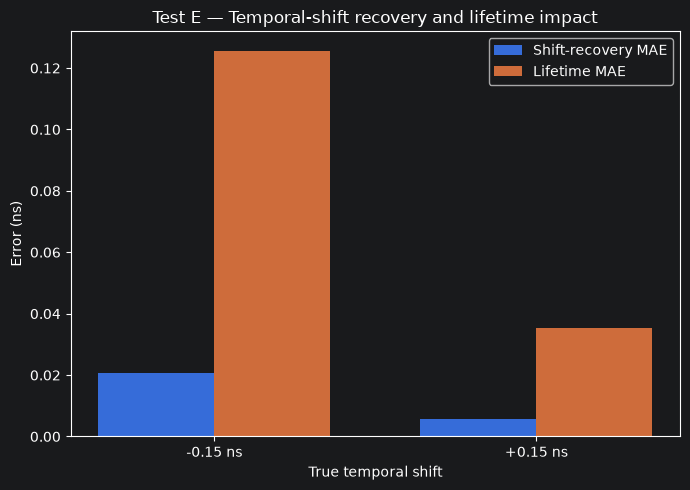

In [49]:
shift_recovery = (
    instrument_diagnostics
    .test_e_shift_recovery
    .copy()
)

x = np.arange(
    len(shift_recovery)
)

width = 0.36

fig, ax = plt.subplots(
    figsize=(7, 5)
)

ax.bar(
    x - width / 2,
    shift_recovery[
        "shift_mae_ns"
    ],
    width=width,
    label="Shift-recovery MAE",
)

ax.bar(
    x + width / 2,
    shift_recovery[
        "lifetime_mae_ns"
    ],
    width=width,
    label="Lifetime MAE",
)

ax.set_xticks(
    x
)

ax.set_xticklabels(
    [
        f"{shift:+.2f} ns"
        for shift
        in shift_recovery[
            "true_shift_ns"
        ]
    ]
)

ax.set_ylabel(
    "Error (ns)"
)

ax.set_xlabel(
    "True temporal shift"
)

ax.set_title(
    "Test E — Temporal-shift recovery and lifetime impact"
)

ax.legend()

fig.tight_layout()
plt.show()

## Day-54 conclusions — Instrument and acquisition mismatch

Tests C–E reveal that the different forms of acquisition mismatch have very different consequences for lifetime estimation.

### Test C — IRF broadening

A broadened IRF is comparatively benign for the non-classical estimators when all other physical conditions remain familiar. For engineered-feature models, the Test-C MAE-degradation factors remain approximately unity: about **1.00 for HistGradientBoosting**, **0.95 for Random Forest**, and **0.99 for Ridge**. Histogram representations show somewhat larger sensitivity in several cases, but the degradation remains modest compared with the other OOD regimes.

Classical reconvolution behaves similarly when the broadened IRF is correctly supplied to the fitter. Its MAE increases only from approximately **0.085 ns** in Test A to **0.095 ns** in Test C, corresponding to a degradation factor of about **1.12**.

The more important result appears when the same Test-C curves are deliberately fitted using the incorrect familiar 0.40-ns IRF. The MAE increases to approximately **0.117 ns**, about **23% worse than fitting Test C with the correct IRF**, and the lifetime bias changes from approximately **−0.016 ns** to **+0.052 ns**.

The paired diagnostics show how the fit responds to the wrong instrument model. The nominal-IRF fit produces an average absolute-error penalty of approximately **0.023 ns**, shifts the fitted temporal offset by about **−0.051 ns**, and increases Poisson deviance by approximately **54 units on average**.

Thus:

> **Broader temporal resolution itself is manageable when the IRF is known, but incorrect knowledge of the IRF causes the reconvolution fit to compensate through other fitted parameters and produces measurable lifetime and goodness-of-fit penalties.**

The fit-failure rate alone does not reliably identify this problem: the deliberately wrong-IRF fit actually has a lower failure rate than the correct-IRF Test-C fit. Model adequacy therefore cannot be inferred solely from optimizer success.

### Test D — Elevated background

Elevated background is the most damaging of the three acquisition shifts for the non-classical estimators.

Across the ML models and representations, Test-D MAE degradation ranges from approximately **1.45 to 4.09**. Engineered-feature Ridge is particularly sensitive, degrading by approximately **4.09**, while engineered-feature Random Forest degrades by about **3.14** and HistGradientBoosting by about **2.13**. The mean-arrival-time estimator also degrades strongly, by approximately **2.56**.

Representation choice matters substantially. For Ridge, normalized-histogram and PCA representations reduce the degradation to approximately **1.78** and **1.45**, respectively, compared with more than fourfold degradation for engineered features.

Classical reconvolution is considerably more robust. Its MAE increases from approximately **0.085 ns** to **0.111 ns**, corresponding to a degradation factor of about **1.31**, while all fits remain valid and the aggregate lifetime bias remains essentially zero.

This behavior is physically consistent with the structure of the estimators: classical reconvolution explicitly includes background as a fitted nuisance parameter, whereas several learned and summary representations are more directly distorted when background increasingly contaminates the decay tail.

The central Test-D result is therefore:

> **Elevated background is a major generalization challenge for the current data-driven estimators, and representation choice strongly affects robustness; explicit nuisance modelling provides classical reconvolution with substantial protection against this shift.**

### Test E — Temporal misalignment

Temporal misalignment produces an intermediate level of degradation for the non-classical estimators and again shows strong representation dependence.

For engineered features, MAE degradation is approximately **1.46 for HistGradientBoosting**, **1.51 for Random Forest**, and **1.62 for Ridge**. Normalized-histogram representations are noticeably more robust: Ridge actually shows a degradation factor slightly below unity, approximately **0.95**, while HistGradientBoosting and Random Forest remain near **1.08** and **1.15**.

Classical reconvolution is particularly robust because temporal shift is an explicit fitted parameter. Its Test-E MAE is approximately **0.080 ns**, slightly lower than its Test-A MAE of approximately **0.085 ns**, and all fits remain valid without boundary hits.

The shift-recovery diagnostics nevertheless reveal a directional asymmetry. For the true **−0.15 ns** shift, the fitted-shift MAE is approximately **0.021 ns** and the resulting lifetime MAE is approximately **0.126 ns**. For the **+0.15 ns** shift, these errors are much smaller, approximately **0.0056 ns** and **0.035 ns**, respectively.

The present experiment therefore shows that the fitter can largely absorb temporal misregistration, but recovery is not perfectly symmetric with respect to shift direction. This asymmetry may reflect the finite acquisition window, IRF geometry, sampling, or their interaction and should not yet be interpreted as a universal sign-dependent effect.

The central Test-E result is:

> **Explicit temporal-shift fitting makes classical reconvolution highly robust to moderate temporal misalignment, while ML robustness depends substantially on representation; the observed sign asymmetry deserves further investigation rather than immediate generalization.**


# Test F — Controlled bi-exponential model mismatch

## Day 55

Tests B–E changed acquisition or instrument conditions while preserving
the mono-exponential decay model.

Test F asks a more fundamental question:

> **What does a mono-exponential lifetime estimator return when the true
> decay is modestly bi-exponential?**

The development data remain strictly:

- mono-exponential;
- Gaussian-IRF convolved;
- Poisson sampled.

Test F changes only the decay model.

Two controlled mismatch severities are used:

- **weak:** 5% of expected detected signal photons originate from the
  secondary component;
- **moderate:** 15% originate from the secondary component.

The secondary lifetime is fixed at

$$
\tau_2 = 2\tau_1.
$$

Importantly, a bi-exponential decay has no unique mono-exponential
"true lifetime".

We therefore retain two references:

1. **primary reference**

$$
\tau_1,
$$

which remains the formal benchmark target;

2. **signal-photon-weighted descriptive reference**

$$
\tau_{\mathrm{ph}}
=
(1-f_2)\tau_1 + f_2\tau_2.
$$

The second quantity is useful for interpreting where an estimator moves
under mismatch, but it is **not** treated as another ground-truth
lifetime.

We also use

$$
r_{\mathrm{eff}}
=
\frac{\hat{\tau}-\tau_1}
     {\tau_2-\tau_1},
$$

where $r_{\mathrm{eff}}=0$ corresponds to the primary lifetime and
$r_{\mathrm{eff}}=1$ to the secondary lifetime.

Values are not clipped to this interval.

In [50]:
test_a_model_mismatch = (
    suite.get_test("A")
)

test_f_model_mismatch = (
    suite.get_test("F")
)

np.testing.assert_array_equal(
    test_a_model_mismatch.metadata[
        "pair_id"
    ].to_numpy(),
    test_f_model_mismatch.metadata[
        "pair_id"
    ].to_numpy(),
)

np.testing.assert_allclose(
    test_a_model_mismatch.y,
    test_f_model_mismatch.y,
)

paired_physical_columns = (
    "signal_photon_count_target",
    "background_per_bin",
    "irf_fwhm_ns",
    "irf_shift_ns",
)

for column in paired_physical_columns:
    np.testing.assert_allclose(
        test_a_model_mismatch.metadata[
            column
        ].to_numpy(),
        test_f_model_mismatch.metadata[
            column
        ].to_numpy(),
    )

print(
    "Test A decay model:",
    test_a_model_mismatch.metadata[
        "decay_model"
    ].unique(),
)

print(
    "Test F decay model:",
    test_f_model_mismatch.metadata[
        "decay_model"
    ].unique(),
)

print(
    "Paired samples:",
    test_f_model_mismatch.y.size,
)

Test A decay model: <StringArray>
['monoexponential']
Length: 1, dtype: str
Test F decay model: <StringArray>
['biexponential']
Length: 1, dtype: str
Paired samples: 192


In [51]:
severity_photon_balance = pd.crosstab(
    test_f_model_mismatch.metadata[
        "model_mismatch_severity"
    ],
    test_f_model_mismatch.metadata[
        "signal_photon_count_target"
    ],
)

severity_photon_balance

signal_photon_count_target,1000,10000
model_mismatch_severity,,
moderate,48,48
weak,48,48


In [52]:
test_f_reference_table = (
    test_f_model_mismatch.metadata[
        [
            "primary_lifetime_ns",
            "secondary_lifetime_ns",
            "model_mismatch_severity",
            "secondary_fraction",
            "signal_photon_weighted_lifetime_ns",
        ]
    ]
    .drop_duplicates()
    .sort_values(
        [
            "secondary_fraction",
            "primary_lifetime_ns",
        ]
    )
    .reset_index(
        drop=True
    )
)

test_f_reference_table

,primary_lifetime_ns,secondary_lifetime_ns,model_mismatch_severity,secondary_fraction,signal_photon_weighted_lifetime_ns
0,1.0,2.0,weak,0.05,1.05
1,2.0,4.0,weak,0.05,2.10
2,3.0,6.0,weak,0.05,3.15
3,4.0,8.0,weak,0.05,4.20
4,1.0,2.0,moderate,0.15,1.15
5,2.0,4.0,moderate,0.15,2.30
6,3.0,6.0,moderate,0.15,3.45
7,4.0,8.0,moderate,0.15,4.60


## Non-classical estimators

We first evaluate the same non-classical estimator family used throughout
Week 8:

- constant development-mean baseline;
- mean-arrival-time estimator;
- Ridge;
- Random Forest;
- HistGradientBoosting.

For the ML models we retain all three representations:

- engineered features;
- normalized histogram;
- PCA histogram.

All fitting remains development-only.

Tests A and F are used exclusively for final prediction and evaluation.

The conventional A-to-F MAE degradation is calculated relative to
$\tau_1$, because $\tau_1$ remains the frozen benchmark target.

However, Test-F interpretation additionally compares predictions with
the signal-photon-weighted descriptive reference.

In [53]:
prepared_model_mismatch = (
    prepare_generalization_data(
        development_measurements=(
            development_measurements
        ),
        tests={
            "A": test_a_model_mismatch,
            "F": test_f_model_mismatch,
        },
        feature_config=(
            FEATURE_CONFIG
        ),
    )
)

fitted_estimators_model_mismatch = (
    fit_generalization_ml_estimators(
        prepared_model_mismatch
    )
)

nonclassical_model_mismatch_result = (
    evaluate_model_mismatch_benchmark(
        prepared=(
            prepared_model_mismatch
        ),
        fitted_estimators=(
            fitted_estimators_model_mismatch
        ),
    )
)

print(
    "Summary rows:",
    len(
        nonclassical_model_mismatch_result
        .summary
    ),
)

print(
    "A-to-F degradation rows:",
    len(
        nonclassical_model_mismatch_result
        .degradation
    ),
)

print(
    "Severity-summary rows:",
    len(
        nonclassical_model_mismatch_result
        .severity_summary
    ),
)

Summary rows: 22
A-to-F degradation rows: 11
Severity-summary rows: 22


## Classical reconvolution under model mismatch

The classical experiment is deliberately stricter.

Both Test A and Test F are fitted with the same mono-exponential
reconvolution model.

For each curve, the fitter receives the **correct IRF width**.

Therefore:

$$
A:
\text{mono-exponential data}
\rightarrow
\text{mono-exponential fit},
$$

whereas

$$
F:
\text{bi-exponential data}
\rightarrow
\text{mono-exponential fit}.
$$

The intended difference is therefore the **decay-model assumption**,
rather than an additional IRF mismatch.

Besides the fitted lifetime, we retain:

- optimizer success and fit validity;
- boundary hits;
- reduced Poisson negative log-likelihood;
- Poisson deviance;
- Poisson deviance per time bin.

Poisson deviance is the more useful goodness-of-fit diagnostic here.

This lets us test an important possibility:

> **Can a mono-exponential fit return a plausible lifetime even when the
> decay shape is no longer well described by the mono-exponential
> model?**

In [54]:
classical_model_mismatch_result = (
    evaluate_classical_model_mismatch_benchmark(
        tests={
            "A": test_a_model_mismatch,
            "F": test_f_model_mismatch,
        },
        irf_centre_ns=(
            definition
            .familiar
            .irf_centre_ns
        ),
    )
)

classical_model_mismatch_result.summary

,estimator,representation,test_id,n_total_samples,n_valid_predictions,mae_ns,median_absolute_error_ns,rmse_ns,bias_ns,p90_absolute_error_ns,p95_absolute_error_ns,classical_failure_rate
0,classical_reconvolution_mono_model,raw_histogram,A,192,192,0.084648,0.047601,0.134432,-0.009579,0.209295,0.345136,0.0
1,classical_reconvolution_mono_model,raw_histogram,F,192,192,0.154911,0.124502,0.206182,0.123573,0.311758,0.388184,0.0


In [55]:
day55_report = (
    build_day55_model_mismatch_report(
        nonclassical_result=(
            nonclassical_model_mismatch_result
        ),
        classical_result=(
            classical_model_mismatch_result
        ),
    )
)

In [56]:
day55_report.nonclassical_comparison[
    [
        "estimator",
        "representation",
        "mae_a",
        "mae_f",
        "bias_a",
        "bias_f",
        "p95_absolute_error_a",
        "p95_absolute_error_f",
        "mae_degradation",
    ]
].sort_values(
    "mae_degradation"
).reset_index(
    drop=True
)

,estimator,representation,mae_a,mae_f,bias_a,bias_f,p95_absolute_error_a,p95_absolute_error_f,mae_degradation
0,constant_mean,none,1.000000,1.000000,0.000000,0.000000,1.500000,1.500000,1.000000
1,hist_gradient_boosting,normalized_histogram,0.276143,0.282816,0.007986,0.098207,0.843390,0.922803,1.024163
2,mean_arrival_time,engineered_features,0.886204,0.921975,0.701415,0.835096,3.127203,3.259817,1.040364
3,ridge,pca_histogram,0.369295,0.391634,0.049489,0.125442,0.815028,0.911139,1.060494
4,random_forest,normalized_histogram,0.284792,0.315990,0.017396,0.101510,0.794500,0.914500,1.109546
5,hist_gradient_boosting,pca_histogram,0.223028,0.249501,-0.000119,0.089068,0.558548,0.606074,1.118696
6,ridge,normalized_histogram,0.235930,0.282683,0.023815,0.132526,0.775512,0.804702,1.198164
7,hist_gradient_boosting,engineered_features,0.219585,0.263451,0.007208,0.118799,0.627636,0.652768,1.199768
8,random_forest,pca_histogram,0.159375,0.193125,0.050521,0.118854,0.779000,0.854500,1.211765
9,ridge,engineered_features,0.192582,0.234296,-0.004503,0.096160,0.557939,0.642149,1.216601


In [57]:
day55_report.severity_comparison[
    [
        "estimator",
        "representation",
        "model_mismatch_severity",
        "secondary_fraction",
        "mae_to_primary_ns",
        "bias_to_primary_ns",
        "mae_to_signal_photon_weighted_ns",
        "bias_to_signal_photon_weighted_ns",
        "mean_effective_mixture_position",
        "median_effective_mixture_position",
        "failure_rate",
    ]
].sort_values(
    [
        "secondary_fraction",
        "mae_to_primary_ns",
    ]
).reset_index(
    drop=True
)

,estimator,representation,model_mismatch_severity,secondary_fraction,mae_to_primary_ns,bias_to_primary_ns,mae_to_signal_photon_weighted_ns,bias_to_signal_photon_weighted_ns,mean_effective_mixture_position,median_effective_mixture_position,failure_rate
0,classical_reconvolution_mono_model,raw_histogram,weak,0.05,0.105416,0.061121,0.100755,-0.063879,0.025575,0.024617,0.0
1,random_forest,engineered_features,weak,0.05,0.138958,0.014583,0.208125,-0.110417,0.021406,0.000000,0.0
2,random_forest,pca_histogram,weak,0.05,0.152812,0.061771,0.220104,-0.063229,0.038307,-0.002500,0.0
3,hist_gradient_boosting,engineered_features,weak,0.05,0.205529,0.019698,0.247270,-0.105302,0.027935,-0.007718,0.0
4,ridge,engineered_features,weak,0.05,0.211131,0.009414,0.233855,-0.115586,0.011263,0.017044,0.0
5,hist_gradient_boosting,pca_histogram,weak,0.05,0.211958,0.022171,0.249618,-0.102829,0.029629,0.017373,0.0
6,ridge,normalized_histogram,weak,0.05,0.244213,0.075321,0.257740,-0.049679,0.089480,0.038892,0.0
7,hist_gradient_boosting,normalized_histogram,weak,0.05,0.281354,0.063500,0.314524,-0.061500,0.058720,0.013456,0.0
8,random_forest,normalized_histogram,weak,0.05,0.292917,0.056458,0.332917,-0.068542,0.079010,0.020000,0.0
9,ridge,pca_histogram,weak,0.05,0.369726,0.070075,0.370271,-0.054925,0.061228,0.048754,0.0


In [58]:
day55_report.classical_comparison[
    [
        "estimator",
        "mae_a",
        "mae_f",
        "bias_a",
        "bias_f",
        "p95_absolute_error_a",
        "p95_absolute_error_f",
        "classical_failure_rate_a",
        "classical_failure_rate_f",
        "mae_degradation",
    ]
]

,estimator,mae_a,mae_f,bias_a,bias_f,p95_absolute_error_a,p95_absolute_error_f,classical_failure_rate_a,classical_failure_rate_f,mae_degradation
0,classical_reconvolution_mono_model,0.084648,0.154911,-0.009579,0.123573,0.345136,0.388184,0.0,0.0,1.83006


In [59]:
day55_report.classical_gof_summary

,model_mismatch_severity,secondary_fraction,n_total_samples,n_valid_fits,failure_rate,boundary_hit_rate,mean_poisson_nll,median_poisson_nll,mean_poisson_deviance,median_poisson_deviance,mean_poisson_deviance_per_bin,median_poisson_deviance_per_bin
0,weak,0.05,96,96,0.0,0.010417,-17865.708060,-15129.239263,424.281429,423.660561,1.060704,1.059151
1,moderate,0.15,96,96,0.0,0.000000,-17441.561426,-14908.571804,426.439343,423.554882,1.066098,1.058887


In [60]:
paired_classical_summary = (
    day55_report
    .classical_paired_diagnostics
    .groupby(
        [
            "model_mismatch_severity",
            "secondary_fraction",
        ],
        as_index=False,
        sort=True,
    )
    .agg(
        n_pairs=(
            "pair_id",
            "size",
        ),
        paired_valid_rate=(
            "paired_valid_fit",
            "mean",
        ),
        mean_fitted_lifetime_change_ns=(
            "fitted_lifetime_change_ns",
            "mean",
        ),
        median_fitted_lifetime_change_ns=(
            "fitted_lifetime_change_ns",
            "median",
        ),
        mean_poisson_deviance_change=(
            "poisson_deviance_change",
            "mean",
        ),
        median_poisson_deviance_change=(
            "poisson_deviance_change",
            "median",
        ),
        mean_poisson_deviance_per_bin_change=(
            "poisson_deviance_per_bin_change",
            "mean",
        ),
        median_poisson_deviance_per_bin_change=(
            "poisson_deviance_per_bin_change",
            "median",
        ),
    )
)

paired_classical_summary

,model_mismatch_severity,secondary_fraction,n_pairs,paired_valid_rate,mean_fitted_lifetime_change_ns,median_fitted_lifetime_change_ns,mean_poisson_deviance_change,median_poisson_deviance_change,mean_poisson_deviance_per_bin_change,median_poisson_deviance_per_bin_change
0,moderate,0.15,96,1.0,0.182100,0.181403,0.734417,1.602830,0.001836,0.004007
1,weak,0.05,96,1.0,0.084202,0.067066,1.638383,-2.861969,0.004096,-0.007155


In [61]:
paired_classical_examples = (
    day55_report
    .classical_paired_diagnostics
    .loc[
        lambda frame: (
            frame[
                "paired_valid_fit"
            ]
        ),
        [
            "pair_id",
            "model_mismatch_severity",
            "secondary_fraction",
            "primary_lifetime_ns",
            "signal_photon_weighted_lifetime_ns",
            "fitted_lifetime_a_ns",
            "fitted_lifetime_f_ns",
            "absolute_error_to_primary_f_ns",
            "absolute_error_to_signal_photon_weighted_f_ns",
            "effective_mixture_position_f",
            "poisson_deviance_per_bin_a",
            "poisson_deviance_per_bin_f",
            "poisson_deviance_per_bin_change",
        ],
    ]
    .sort_values(
        "poisson_deviance_per_bin_change",
        ascending=False,
    )
    .head(12)
    .reset_index(
        drop=True
    )
)

paired_classical_examples

,pair_id,model_mismatch_severity,secondary_fraction,primary_lifetime_ns,signal_photon_weighted_lifetime_ns,fitted_lifetime_a_ns,fitted_lifetime_f_ns,absolute_error_to_primary_f_ns,absolute_error_to_signal_photon_weighted_f_ns,effective_mixture_position_f,poisson_deviance_per_bin_a,poisson_deviance_per_bin_f,poisson_deviance_per_bin_change
0,183,moderate,0.15,4.0,4.60,4.030403,4.279483,0.279483,0.320517,0.069871,0.918449,1.206442,0.287993
1,3,moderate,0.15,1.0,1.15,0.994028,1.055045,0.055045,0.094955,0.055045,0.920845,1.151931,0.231086
2,38,moderate,0.15,1.0,1.15,0.996056,1.015586,0.015586,0.134414,0.015586,0.997309,1.223597,0.226288
3,41,weak,0.05,1.0,1.05,0.987786,1.029179,0.029179,0.020821,0.029179,0.899502,1.118477,0.218975
4,31,moderate,0.15,1.0,1.15,0.966195,1.041579,0.041579,0.108421,0.041579,1.071148,1.285688,0.214541
5,9,weak,0.05,1.0,1.05,1.000657,1.015503,0.015503,0.034497,0.015503,0.937097,1.140119,0.203022
6,81,weak,0.05,2.0,2.10,1.997792,2.056343,0.056343,0.043657,0.028172,0.953082,1.140448,0.187366
7,119,moderate,0.15,3.0,3.45,3.053873,3.215818,0.215818,0.234182,0.071939,0.887672,1.074170,0.186498
8,50,moderate,0.15,2.0,2.30,1.828854,2.087589,0.087589,0.212411,0.043795,0.959369,1.142370,0.183001
9,128,weak,0.05,3.0,3.15,2.839292,3.124828,0.124828,0.025172,0.041609,1.026951,1.188840,0.161890


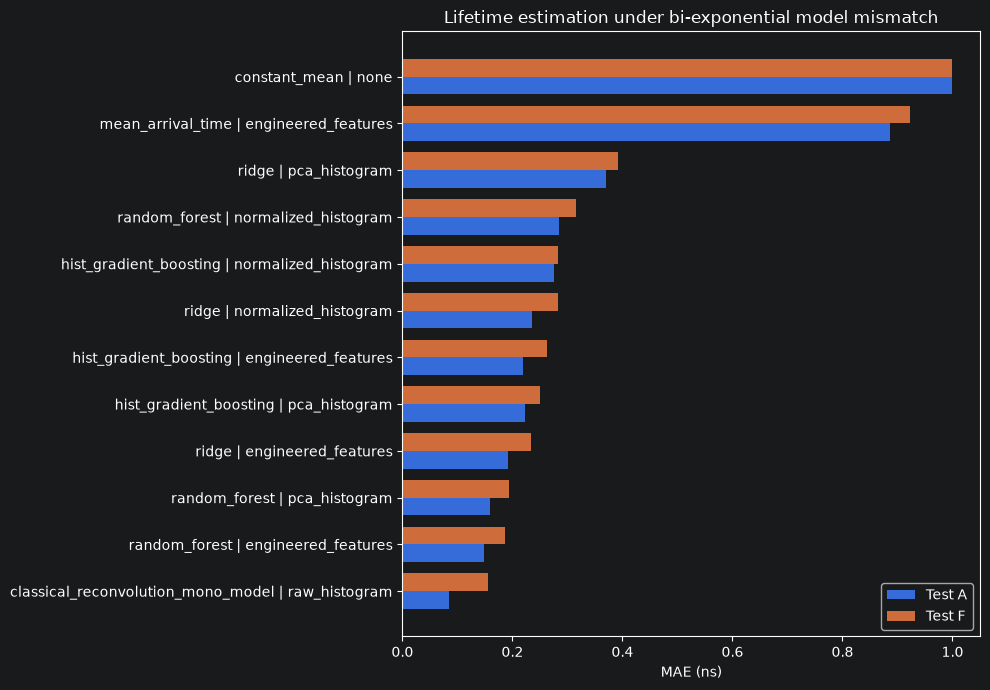

In [62]:
af_plot = pd.concat(
    [
        day55_report.nonclassical_comparison[
            [
                "estimator",
                "representation",
                "mae_a",
                "mae_f",
            ]
        ],
        day55_report.classical_comparison[
            [
                "estimator",
                "representation",
                "mae_a",
                "mae_f",
            ]
        ],
    ],
    ignore_index=True,
)

af_plot["label"] = (
    af_plot["estimator"]
    + " | "
    + af_plot["representation"]
)

af_plot = (
    af_plot
    .sort_values(
        "mae_f"
    )
    .reset_index(
        drop=True
    )
)

y = np.arange(
    len(af_plot)
)

bar_height = 0.38

fig, ax = plt.subplots(
    figsize=(10, 7)
)

ax.barh(
    y - bar_height / 2,
    af_plot["mae_a"],
    height=bar_height,
    label="Test A",
)

ax.barh(
    y + bar_height / 2,
    af_plot["mae_f"],
    height=bar_height,
    label="Test F",
)

ax.set_yticks(
    y
)

ax.set_yticklabels(
    af_plot["label"]
)

ax.set_xlabel(
    "MAE (ns)"
)

ax.set_title(
    "Lifetime estimation under bi-exponential model mismatch"
)

ax.legend()

fig.tight_layout()
plt.show()

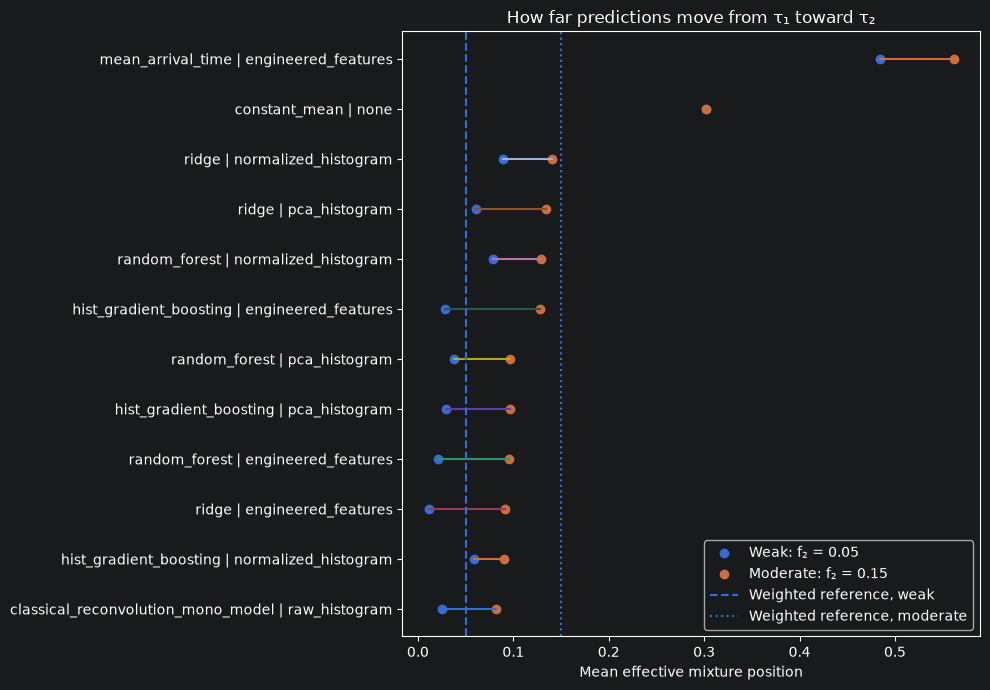

In [63]:
mixture_plot = (
    day55_report
    .severity_comparison
    .copy()
)

mixture_plot["label"] = (
    mixture_plot["estimator"]
    + " | "
    + mixture_plot["representation"]
)

mixture_pivot = (
    mixture_plot.pivot(
        index="label",
        columns="model_mismatch_severity",
        values="mean_effective_mixture_position",
    )
)

mixture_pivot = (
    mixture_pivot
    .sort_values(
        "moderate"
    )
)

y = np.arange(
    len(mixture_pivot)
)

fig, ax = plt.subplots(
    figsize=(10, 7)
)

ax.scatter(
    mixture_pivot["weak"],
    y,
    label="Weak: f₂ = 0.05",
)

ax.scatter(
    mixture_pivot["moderate"],
    y,
    label="Moderate: f₂ = 0.15",
)

for index in range(
    len(mixture_pivot)
):
    ax.plot(
        [
            mixture_pivot["weak"].iloc[index],
            mixture_pivot["moderate"].iloc[index],
        ],
        [
            y[index],
            y[index],
        ],
    )

ax.axvline(
    0.05,
    linestyle="--",
    label="Weighted reference, weak",
)

ax.axvline(
    0.15,
    linestyle=":",
    label="Weighted reference, moderate",
)

ax.set_yticks(
    y
)

ax.set_yticklabels(
    mixture_pivot.index
)

ax.set_xlabel(
    "Mean effective mixture position"
)

ax.set_title(
    "How far predictions move from τ₁ toward τ₂"
)

ax.legend()

fig.tight_layout()
plt.show()

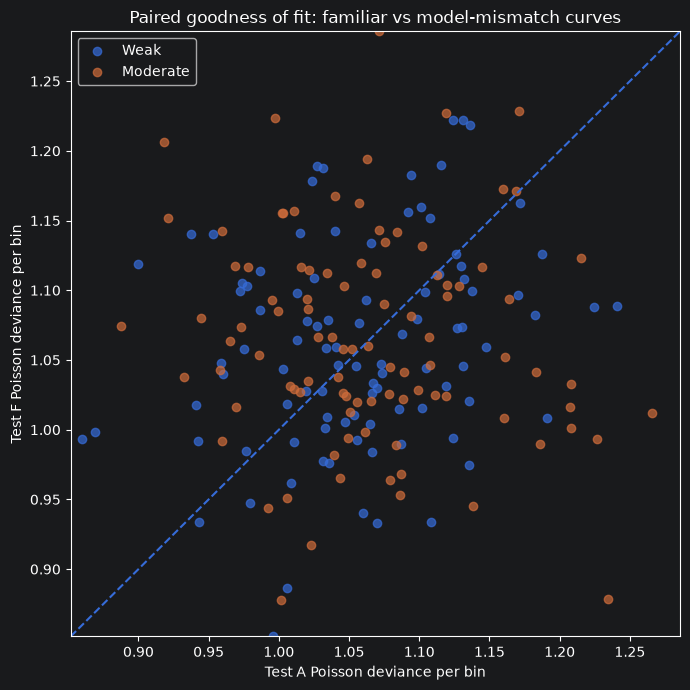

In [64]:
paired = (
    day55_report
    .classical_paired_diagnostics
)

fig, ax = plt.subplots(
    figsize=(7, 7)
)

for severity in (
    "weak",
    "moderate",
):
    subset = paired.loc[
        paired[
            "model_mismatch_severity"
        ] == severity
    ]

    ax.scatter(
        subset[
            "poisson_deviance_per_bin_a"
        ],
        subset[
            "poisson_deviance_per_bin_f"
        ],
        alpha=0.7,
        label=severity.capitalize(),
    )

limits = [
    min(
        paired[
            "poisson_deviance_per_bin_a"
        ].min(),
        paired[
            "poisson_deviance_per_bin_f"
        ].min(),
    ),
    max(
        paired[
            "poisson_deviance_per_bin_a"
        ].max(),
        paired[
            "poisson_deviance_per_bin_f"
        ].max(),
    ),
]

ax.plot(
    limits,
    limits,
    linestyle="--",
)

ax.set_xlim(
    limits
)

ax.set_ylim(
    limits
)

ax.set_xlabel(
    "Test A Poisson deviance per bin"
)

ax.set_ylabel(
    "Test F Poisson deviance per bin"
)

ax.set_title(
    "Paired goodness of fit: familiar vs model-mismatch curves"
)

ax.legend()

fig.tight_layout()
plt.show()

## Day-55 conclusions — Controlled bi-exponential model mismatch

Test F probes a qualitatively different robustness problem from Tests B–E. Rather than changing acquisition or instrument conditions, it violates the mono-exponential decay-model assumption itself while preserving the paired lifetime, photon-count, background, IRF-width, and temporal-alignment conditions of Test A.

The controlled mismatch produces a clear and systematic effect on lifetime estimation. Across the non-classical estimators, Test-F MAE generally increases relative to Test A, with degradation factors ranging from approximately **1.02 to 1.25** for the informative estimators. The best absolute non-classical Test-F performance is obtained by **Random Forest with engineered features**, with

$$
\mathrm{MAE}_F \approx 0.186\ \mathrm{ns},
$$

compared with

$$
\mathrm{MAE}_A \approx 0.149\ \mathrm{ns}.
$$

The degradation is therefore real, but not catastrophic. Importantly, most estimators also acquire a more positive bias under Test F. This indicates that the secondary long-lifetime component systematically pulls the mono-exponential estimate upward.

The severity analysis makes this interpretation clearer. Increasing the secondary detected-signal fraction from **5% to 15%** increases the error relative to the primary lifetime $\tau_1$ for essentially all useful estimators. For the classical reconvolution estimator, for example,

$$
\mathrm{MAE}_{\tau_1}
$$

increases from approximately

$$
0.105\ \mathrm{ns}
$$

for weak mismatch to

$$
0.204\ \mathrm{ns}
$$

for moderate mismatch.

However, the fitted values do not simply converge to the signal-photon-weighted descriptive lifetime. The effective mixture position

$$
r_{\mathrm{eff}}
=
\frac{\hat{\tau}-\tau_1}
     {\tau_2-\tau_1}
$$

remains relatively close to the dominant lifetime for most estimators. For classical reconvolution, the mean $(r_{\mathrm{eff}}$ rises only from approximately **0.026** under weak mismatch to **0.082** under moderate mismatch, whereas the signal-photon-weighted references correspond to positions 0.05 and 0.15, respectively. Thus, the mono-exponential fit responds to the secondary component, but only partially follows this particular descriptive mixture reference.

Classical reconvolution is especially informative. Its aggregate MAE increases from

$$
0.085\ \mathrm{ns}
$$

in Test A to

$$
0.155\ \mathrm{ns}
$$

in Test F, corresponding to an MAE degradation factor of approximately

$$
1.83.
$$

At the same time, **all 192 Test-A fits and all 192 Test-F fits remain valid**, with zero fit-failure rate. The moderate Test-F curves shift the fitted lifetime upward by approximately **0.182 ns on average**, compared with approximately **0.084 ns** for weak contamination.

Crucially, this parameter bias is **not accompanied by a strong aggregate deterioration in Poisson goodness of fit**. The mean Poisson deviance per bin is approximately

$$
1.061
$$

for weak mismatch and

$$
1.066
$$

for moderate mismatch. Relative to the paired Test-A curves, the average deviance-per-bin changes are only about

$$
0.0041
$$

and

$$
0.0018,
$$

respectively. The median paired change is even slightly negative for the weak-mismatch subset.

Therefore, at the controlled mismatch levels studied here, Poisson deviance does **not** provide a strong global warning that the mono-exponential model is misspecified. Individual curves can show substantially larger deterioration — the strongest inspected cases increase the deviance per bin by roughly $0.15$–$0.29$ — but this signal is not consistently visible in aggregate statistics.

The central Day-55 result is therefore:

> **A modest bi-exponential component can be absorbed by a mono-exponential estimator primarily as a shift in the reported lifetime, while optimization remains successful and aggregate goodness-of-fit diagnostics may remain deceptively normal.**

This means that a plausible fitted lifetime, optimizer success, and even an apparently acceptable Poisson deviance are not sufficient evidence that the assumed lifetime model is physically correct.

For the ML estimators the limitation is stronger still: they currently return point predictions without an explicit goodness-of-fit diagnostic at all. Their moderate Test-F degradation demonstrates that they respond systematically to decay-model mismatch, but the prediction itself does not indicate whether the input remains compatible with the distribution or physical model on which the estimator was trained.

Test F therefore provides a direct motivation for Week 9. Robust lifetime estimation should ultimately supplement the point estimate with **uncertainty, confidence, or model-mismatch awareness**, rather than relying on prediction accuracy or optimizer success alone.
